In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import numpy as np
import pandas as pd

In [3]:
sys.path.append("/home/chenxufeng/WorkSpace/scMagnify/src/")
from grn_tools import *

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

## Configurations

In [6]:
%matplotlib inline

matplotlib.rcParams["figure.figsize"] = [4, 4]
matplotlib.rcParams["figure.dpi"] = 150
matplotlib.rcParams["savefig.dpi"] = 300
matplotlib.rcParams["font.family"] = "Arial"
matplotlib.rcParams["image.cmap"] = "Spectral_r"

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["text.usetex"] = False

In [7]:
algo_palette = {
    "scMagnify": "#ff7f0e",
    "CellOracle": "#1f77b4",
}

# Calculate the Metrics

In [8]:
metrics_df = batch_evaluate_scMultiSim(
    algo_list = ["CellOracle", "scMagnify"]
)

Output()

In [9]:
metrics_df.head()

,Algorithm,Dataset,Nums_TF,Nums_Target,Precsions,Recalls,AUPR,AUPR Ratio1,AUPR Ratio2,FPRs,TPRs,AUROC,Confusion Matrix,Precision,Recall,F1 Score(topk),F0.1 Score(topk)
0,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_5,6,1130,"[0.21009389671361503, 0.7344188658057271, 0.73...","[1.0, 0.9134078212290503, 0.9127094972067039, ...",0.771811,3.673649,3.770879,"[0.0, 0.0, 0.0, 0.00018573551263001485, 0.0001...","[0.0, 0.0006983240223463687, 0.005586592178770...",0.924468,"[[4911, 473], [124, 1308]]",0.734419,0.913408,0.814192,0.735847
1,CellOracle,grn1139_noise_tree1_1000_cells1139_genes_sigma...,6,1130,"[0.21009389671361503, 0.7475504322766571, 0.74...","[1.0, 0.9057262569832403, 0.9050279329608939, ...",0.759539,3.615237,3.657784,"[0.0, 0.0, 0.0, 0.00018573551263001485, 0.0001...","[0.0, 0.0006983240223463687, 0.018854748603351...",0.918928,"[[4946, 438], [135, 1297]]",0.747550,0.905726,0.819072,0.748845
2,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_8,6,1130,"[0.21009389671361503, 0.7422272470322216, 0.74...","[1.0, 0.9168994413407822, 0.9162011173184358, ...",0.734898,3.497950,3.521819,"[0.0, 0.00018573551263001485, 0.00037147102526...","[0.0, 0.0, 0.0, 0.0006983240223463687, 0.00069...",0.924330,"[[4928, 456], [119, 1313]]",0.742227,0.916899,0.820369,0.743630
3,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_7,6,1130,"[0.21009389671361503, 0.7429245283018868, 0.74...","[1.0, 0.8798882681564246, 0.8791899441340782, ...",0.747375,3.557336,3.572254,"[0.0, 0.0, 0.0, 0.00018573551263001485, 0.0001...","[0.0, 0.0006983240223463687, 0.017458100558659...",0.908072,"[[4948, 436], [172, 1260]]",0.742925,0.879888,0.805627,0.744071
4,CellOracle,grn100_noise_tree1_1000_cells110_genes_sigma0....,6,94,"[0.21666666666666667, 0.21885521885521886, 0.2...","[1.0, 1.0, 0.9923076923076923, 0.9923076923076...",0.398909,1.841120,1.801371,"[0.0, 0.0, 0.006382978723404255, 0.00638297872...","[0.0, 0.007692307692307693, 0.0076923076923076...",0.702987,"[[6, 464], [0, 130]]",0.218855,1.000000,0.359116,0.220561


In [10]:
metrics_df[	["Algorithm", "Dataset", "AUPR", "AUROC"]]

,Algorithm,Dataset,AUPR,AUROC
0,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_5,0.771811,0.924468
1,CellOracle,grn1139_noise_tree1_1000_cells1139_genes_sigma...,0.759539,0.918928
2,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_8,0.734898,0.924330
3,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_7,0.747375,0.908072
4,CellOracle,grn100_noise_tree1_1000_cells110_genes_sigma0....,0.398909,0.702987
...,...,...,...,...
475,scMagnify,grn100_tree1_1000_cells110_genes_sigma0.1_6_p0.05,0.635452,0.781195
476,scMagnify,grn100_tree1_1000_cells110_genes_sigma0.1_8_p0.05,0.610314,0.801473
477,scMagnify,grn100_noise_tree1_1000_cells110_genes_sigma0....,0.300072,0.606285
478,scMagnify,grn100_tree1_1000_cells500_genes_sigma0.1_1_p0.05,0.580269,0.837332


In [11]:
import re
def update_algorithm_name(row):
    dataset = row['Dataset']
    # Check for patterns like p0.01, p0.1, p0.5 in the Dataset
    match = re.search(r'(p\d\.\d+)', dataset)
    if match:
        noise_level = match.group(1)
        return f"{row['Algorithm']}_{noise_level}"
    return row['Algorithm']

# Apply the function to update the Algorithm column
metrics_df['Algorithm'] = metrics_df.apply(update_algorithm_name, axis=1)

<Axes: >

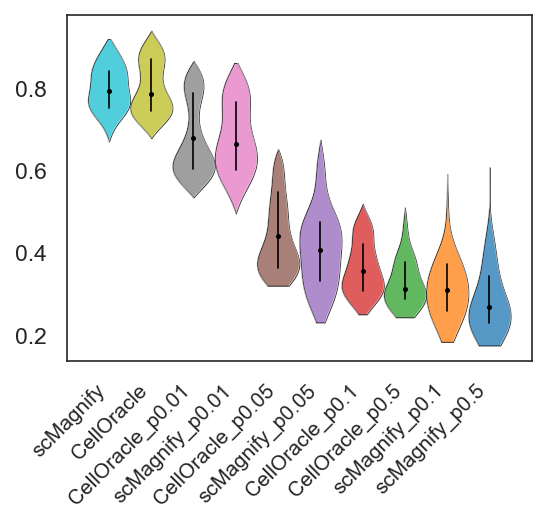

In [87]:
plot_violin(metrics_df, x="Algorithm", y="AUPR", figsize=(5, 5), spline_linewidth=0.8)

## Filter the Metrics

In [12]:
filtered_metrics_grn100 = metrics_df[metrics_df["Dataset"].str.contains("grn100")]
filtered_metrics_grn100_raw = filtered_metrics_grn100[~metrics_df["Dataset"].str.contains("noise")]
filtered_metrics_grn100_noise = filtered_metrics_grn100[metrics_df["Dataset"].str.contains("noise")]

/var/tmp/ipykernel_19394/1907363389.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_metrics_grn100_raw = filtered_metrics_grn100[~metrics_df["Dataset"].str.contains("noise")]
/var/tmp/ipykernel_19394/1907363389.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_metrics_grn100_noise = filtered_metrics_grn100[metrics_df["Dataset"].str.contains("noise")]


<Axes: >

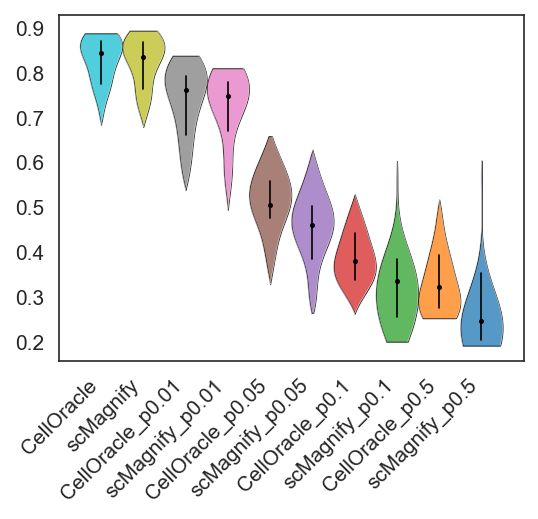

In [13]:
plot_violin(filtered_metrics_grn100_raw, x="Algorithm", y="AUPR", figsize=(5, 5), spline_linewidth=0.8)

<Axes: >

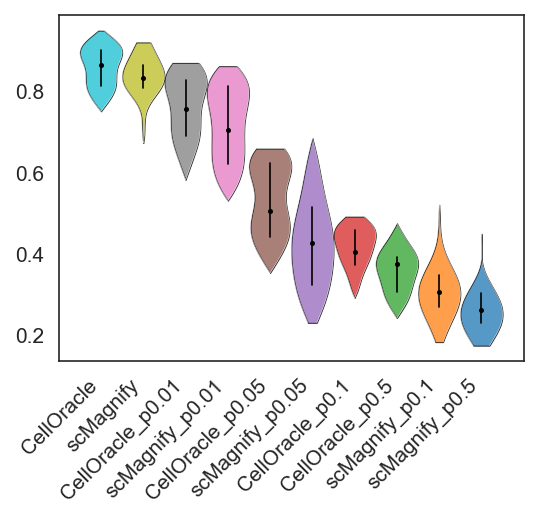

In [14]:
plot_violin(filtered_metrics_grn100_noise, x="Algorithm", y="AUPR", figsize=(5, 5), spline_linewidth=0.8)

<Axes: >

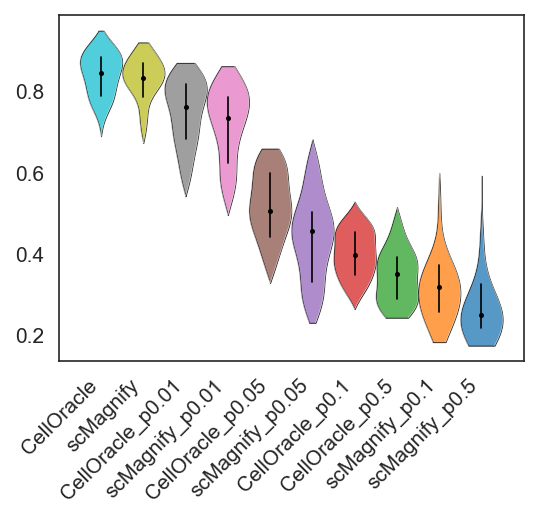

In [15]:
plot_violin(filtered_metrics_grn100, x="Algorithm", y="AUPR", figsize=(5, 5), spline_linewidth=0.8)

In [16]:
filtered_metrics_grn1139 = metrics_df[metrics_df["Dataset"].str.contains("grn1139")]
filtered_metrics_grn1139_raw = filtered_metrics_grn1139[~metrics_df["Dataset"].str.contains("noise")]
filtered_metrics_grn1139_noise = filtered_metrics_grn1139[metrics_df["Dataset"].str.contains("noise")]

/var/tmp/ipykernel_19394/2063591068.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_metrics_grn1139_raw = filtered_metrics_grn1139[~metrics_df["Dataset"].str.contains("noise")]
/var/tmp/ipykernel_19394/2063591068.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_metrics_grn1139_noise = filtered_metrics_grn1139[metrics_df["Dataset"].str.contains("noise")]


<Axes: >

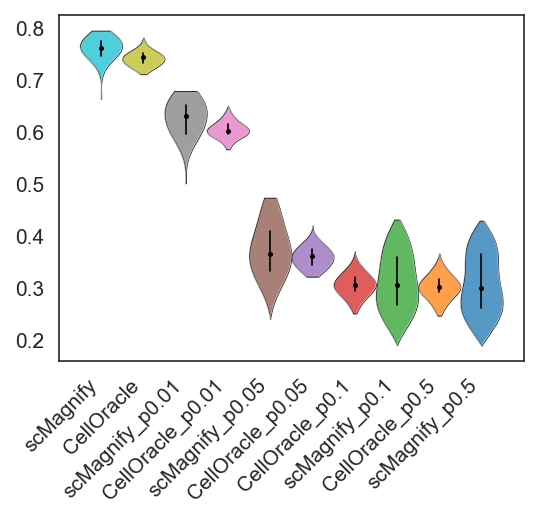

In [17]:
plot_violin(filtered_metrics_grn1139, x="Algorithm", y="AUPR", figsize=(5, 5), spline_linewidth=0.8)

<Axes: >

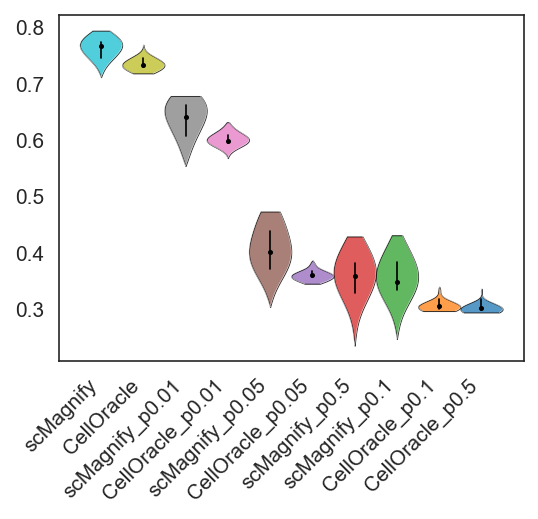

In [18]:
plot_violin(filtered_metrics_grn1139_raw, x="Algorithm", y="AUPR", figsize=(5, 5), spline_linewidth=0.8)

<Axes: >

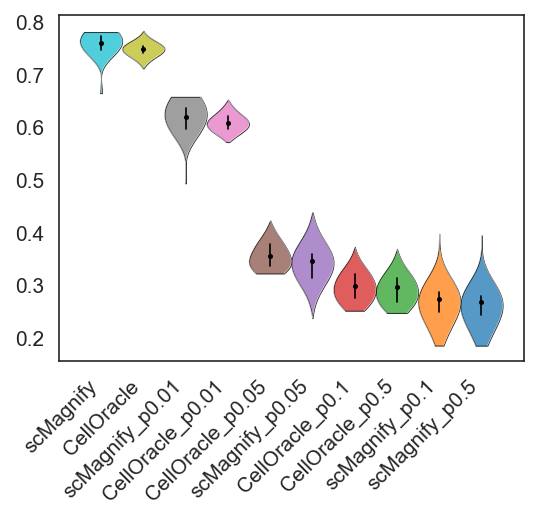

In [19]:
plot_violin(filtered_metrics_grn1139_noise, x="Algorithm", y="AUPR", figsize=(5, 5), spline_linewidth=0.8)

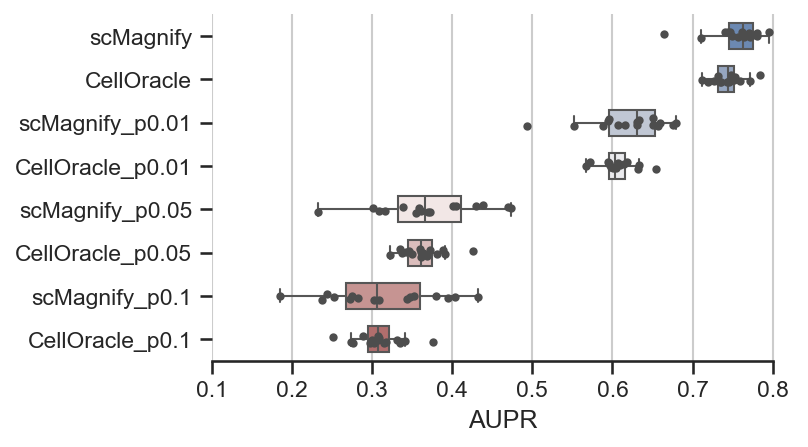

In [21]:
matplotlib.rcParams["figure.dpi"] = 150

# order = ["scMagnify", "scMagnify_p0.01", "scMagnify_p0.1", "scMagnify_p0.5",
#          "CellOracle", "CellOracle_p0.01", "CellOracle_p0.1", "CellOracle_p0.5"]

order = ["scMagnify", "CellOracle",
         "scMagnify_p0.01", "CellOracle_p0.01",
         "scMagnify_p0.05", "CellOracle_p0.05",
         "scMagnify_p0.1", "CellOracle_p0.1"]

sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(5, 3))
# ax.set_xscale("log")

# Plot the orbital period with horizontal boxes
sns.boxplot(
    filtered_metrics_grn1139, x="AUPR", y="Algorithm", hue="Algorithm",
    order=order, hue_order=order,
    width=.6, palette="vlag", 
    flierprops=dict(
        marker='D',        
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=0,
        linestyle='none'
    )
)

# Add in points to show each observation
sns.stripplot(filtered_metrics_grn1139, x="AUPR", y="Algorithm", size=4, color=".3", order=order)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

sns.despine(trim=True, left=True)

plt.savefig("./scmultisim_aupr.pdf", bbox_inches='tight', transparent=True)

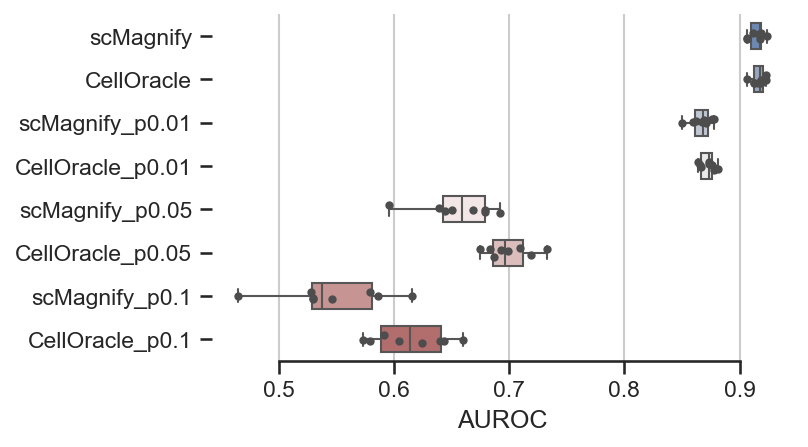

In [98]:
matplotlib.rcParams["figure.dpi"] = 150

# order = ["scMagnify", "scMagnify_p0.01", "scMagnify_p0.1", "scMagnify_p0.5",
#          "CellOracle", "CellOracle_p0.01", "CellOracle_p0.1", "CellOracle_p0.5"]

order = ["scMagnify", "CellOracle",
         "scMagnify_p0.01", "CellOracle_p0.01",
         "scMagnify_p0.05", "CellOracle_p0.05",
         "scMagnify_p0.1", "CellOracle_p0.1"]

sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(5, 3))
# ax.set_xscale("log")

# Plot the orbital period with horizontal boxes
sns.boxplot(
    filtered_metrics_grn1139_noise, x="AUROC", y="Algorithm", hue="Algorithm",
    order=order, hue_order=order,
    width=.6, palette="vlag", 
    flierprops=dict(
        marker='D',      
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=0,
        linestyle='none'
    )
)

# Add in points to show each observation
sns.stripplot(filtered_metrics_grn1139_noise, x="AUROC", y="Algorithm", size=4, color=".3", order=order)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
# ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

sns.despine(trim=True, left=True)

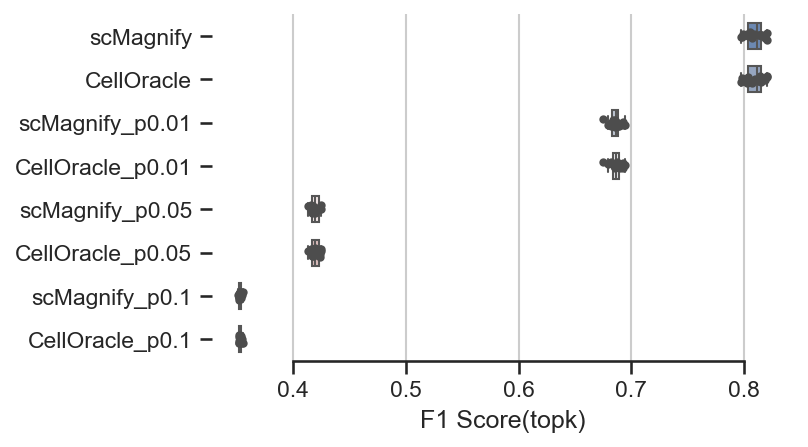

In [96]:
matplotlib.rcParams["figure.dpi"] = 150

# order = ["scMagnify", "scMagnify_p0.01", "scMagnify_p0.1", "scMagnify_p0.5",
#          "CellOracle", "CellOracle_p0.01", "CellOracle_p0.1", "CellOracle_p0.5"]

order = ["scMagnify", "CellOracle",
         "scMagnify_p0.01", "CellOracle_p0.01",
         "scMagnify_p0.05", "CellOracle_p0.05",
         "scMagnify_p0.1", "CellOracle_p0.1"]

sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(5, 3))
# ax.set_xscale("log")

# Plot the orbital period with horizontal boxes
sns.boxplot(
    filtered_metrics_grn1139, x="F1 Score(topk)", y="Algorithm", hue="Algorithm",
    order=order, hue_order=order,
    width=.6, palette="vlag", 
    flierprops=dict(
        marker='D',      
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=0,
        linestyle='none'
    )
)

# Add in points to show each observation
sns.stripplot(filtered_metrics_grn1139, x="F1 Score(topk)", y="Algorithm", size=4, color=".3", order=order)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
# ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

sns.despine(trim=True, left=True)